# Model prediction with the landscape model: Early Pulse experiment
*Condition: SAGUP (0nM SAG → 500nM SAG → 0nM SAG)*

<br>

In this notebook, we simulate the global landscape model in [1] for the Early Pulse experiment **SAGUP**, where cells are exposed to 0nM SAG for 12h, followed by 500nM SAG for 12h and then 0nM SAG. To do this we use the parameters obtained from fitting the model to data exposed to the constant SAG concentrations 0nM and 500nM in the notebooks `Fitting_Flow_SAG0.ipynb` and `Fitting_Flow_SAG500.ipynb`, so the simulation is a *prediction*: only the two response times $T_1$ and $T_2$ are fitted here.

This covers Appendix B (Modelling & estimation) [2] of [1]:

* __Section B6:__ Model predictions using flow cytometry data *(done in this notebook)*,
  * __Section B6.1:__ Early pulse experiment,
  * __Section B6.2:__ Model simulation and prediction.

The prediction machinery is in `prediction_global_earlypulse.py` and the plotting helpers are in `fitting_plots.py`.

[1] M. Fontaine, J.M. Delas, M. Saez, R.J. Maizels, E. Finnie, J. Briscoe, D.A. Rand, (2025). *Dynamic Landscape Analysis of Cell Fate Decisions: Predictive Models of Neural Development From Single-Cell Data*. bioR$\chi$iv doi: https://doi.org/10.1101/2025.05.28.656648.

[2] M. Fontaine, J.M. Delas, M. Saez, R.J. Maizels, E. Finnie, J. Briscoe, D.A. Rand, (2025). *Appendix B: Modelling & estimation*. figshare doi: https://doi.org/10.6084/m9.figshare.31342816.

---
<sub>Author: Marine Fontaine (Warwick)</sub>

### **1.** Load packages

In [3]:
import os
import sys
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **2.** Import experimental proportions

In [6]:
wd = 'Experimental_and_Simulated_Proportions_Flow/'  # relative to this notebook

adata = pd.read_csv(wd + 'Proportions_EarlyPulse_SAGUP.csv')*100

#keep only attractor clusters except FP
adata = adata.loc[:, ~adata.columns.str.contains('other|pMNTrans|DPTrans|PreNTrans|p2Trans')] 
adata1 = adata.loc[:, ~adata.columns.str.contains('FP')] # FP result used as prediction so we remove it for fitting

# Convert DataFrame to numpy array, divide by 100, and round to two decimal places
processed_data = np.round(adata1.to_numpy() /100, 2).flatten()
# Create dictionary with the processed data for Pyabc
data = {'X_2': processed_data}

adata1.index=['D3.5','D4','D5','D6']
adata.index=['D3.5','D4','D5','D6']
adata1  

,PreNeural,p0/p1,p2,pMN,MNDiff,DP,EarlyVentral,Early p3,p3
D3.5,25.704320,22.189428,0.000000,0.000000,0.000000,0.000000,0.000000,0.134156,0.000000
D4,4.163192,18.955674,24.562191,2.713452,0.006415,1.250882,1.635769,1.821797,0.070563
D5,4.337276,3.867152,5.656658,20.723385,0.485290,11.336063,4.458599,8.113436,3.397028
D6,0.556586,1.437848,0.123686,13.218924,33.750773,22.309833,2.118120,4.607297,5.720470


### **3.** Pulse simulation using previously obtained parameters

In [9]:
# Import functions to simulate and compute distance
from prediction_global_earlypulse import model, distance_sim, sim_predict
# Import the function to plot the distributions of simulated data
from fitting_plots import plot_tendencies

In [10]:
# Simulate using fitted parameters
simD35=sim_predict({'T1': 50,'T2':100},500)

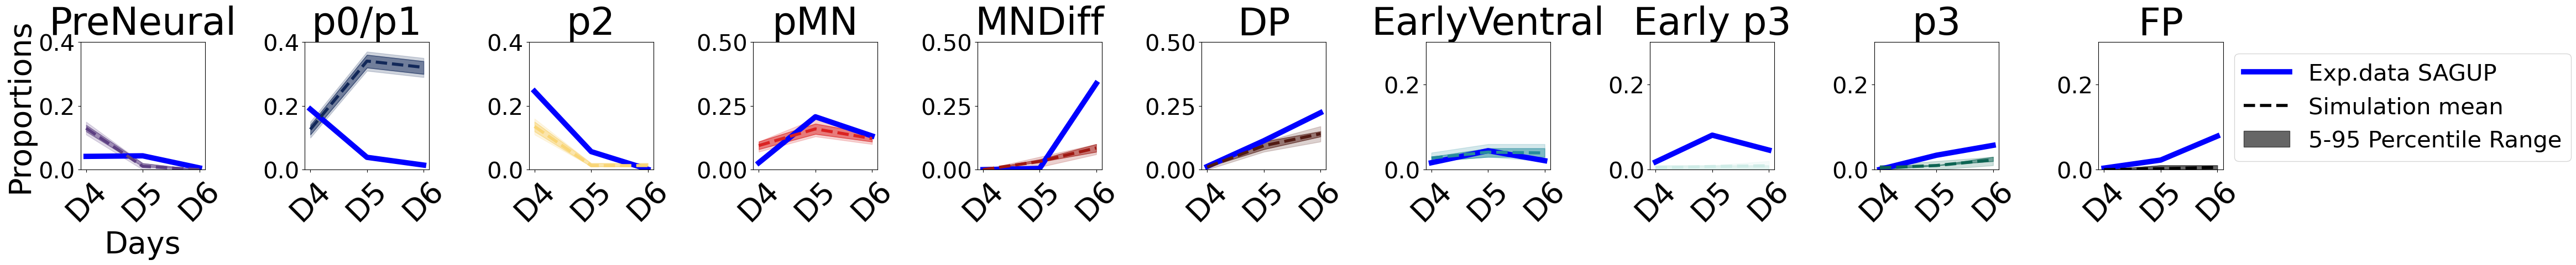

In [14]:
# define colors for plot
colorpalette={'PreNeural':'#5D4082',
              'p0/p1':'#122859',
              'p2':'#F9D575',
              'pMN':'#DA2222',
              'DP':'#511A13',
              'EarlyVentral':'#288c9c',
              'Early p3':'#CFECE7',
              'p3':'#0D6453',
              'FP':'#000000',
              'MNDiff':'#9F1812'}

# define states
states=['PreNeural','p0/p1','p2','pMN','MNDiff','DP','EarlyVentral','Early p3','p3','FP']

# plot simulated proportions (keep only the columns of the days shown, in the order
# plot_tendencies rebuilds them)
plotdays = ['D4','D5','D6']
cols = [f"{s}-{d}" for d in plotdays for s in states]
plot_tendencies(states, plotdays, simD35[cols], adata, colorpalette)

### **4.** ABC Fitting

The plot above (p0/p1 panel) shows that, at D4, the p0/p1 attractors are re-established, preventing cells that have not yet transitioned to p2 from progressing further. As a result, the simulation displays a stable proportion of p0/p1 cells plateauing around 30%. In contrast, the experimental data indicate a continued decline in the proportion of p0/p1 cells, with no apparent response to the change in concentration from 500nM to 0nM. To investigate this further, we apply Pyabc [3,4] to adjust the time response $T_1$ (was D3.5) to the change of concentration from 0nM and the response $T_2$ (D4) to the change of concentration from 500nM to 0nM.

[3] Y. Schälte, E. Klinger, E. Alamoudi, and J. Hasenauer, (2022). *pyABC: Efficient and robust easy-to-use approximate Bayesian computation*. Journal of Open Source Software, 7(74), 4304, https://doi.org/10.21105/joss.04304.

[4] E. Klinger, D. Rickert, and J. Hasenauer, (2018). *pyABC: distributed, likelihood-free inference*. Bioinformatics, 34(20). https://doi.org/10.1093/bioinformatics/bty361.

In [17]:
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition, MedianEpsilon

# Create path to store Pyabc history
path = '.../DynamicalLandscapeAnalysis_v2/FittingGlobalModel'
db_path = "sqlite:///" + os.path.join(tempfile.gettempdir(), "FittingFlowEarlyPulse.db")

# Define priors
limits = dict(T1=(50, 200),
             T2=(100,400))
prior = Distribution(**{key: RV("uniform", a, b - a)
for key, (a,b) in limits.items()})

In [19]:
import pyabc
abc = ABCSMC(
    models=model,
    parameter_priors=prior,
    distance_function=distance_sim,
    population_size=500,
    transitions=LocalTransition(k_fraction=0.3),
    eps=pyabc.QuantileEpsilon(alpha=0.2),
)

abc.new(db_path, data);

h = abc.run(minimum_epsilon=0.1, max_nr_populations=3)
run_id = h.id
print("Run ID:", run_id)

ABC.Sampler INFO: Parallelize sampling on 12 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2025-06-03 11:45:40>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 1.78500000e+00.
ABC INFO: Accepted: 500 / 2512 = 1.9904e-01, ESS: 5.0000e+02.
ABC INFO: t: 1, eps: 1.64000000e+00.
ABC INFO: Accepted: 500 / 2239 = 2.2331e-01, ESS: 4.7898e+02.
ABC INFO: t: 2, eps: 1.60000000e+00.
ABC INFO: Accepted: 500 / 5321 = 9.3967e-02, ESS: 4.1666e+02.
ABC INFO: Stop: Maximum number of generations.
ABC.History INFO: Done <ABCSMC id=1, duration=0:18:21.178089, end_time=2025-06-03 12:04:01>


Run ID: 1


#### **4.1** Visualise the posterior parameter distribution

In [21]:
df, w = h.get_distribution(m=0)
df.head(3)

name,T1,T2
id,,
1002,68.578922,386.785287
1003,63.394386,347.990396
1004,83.819131,350.012312


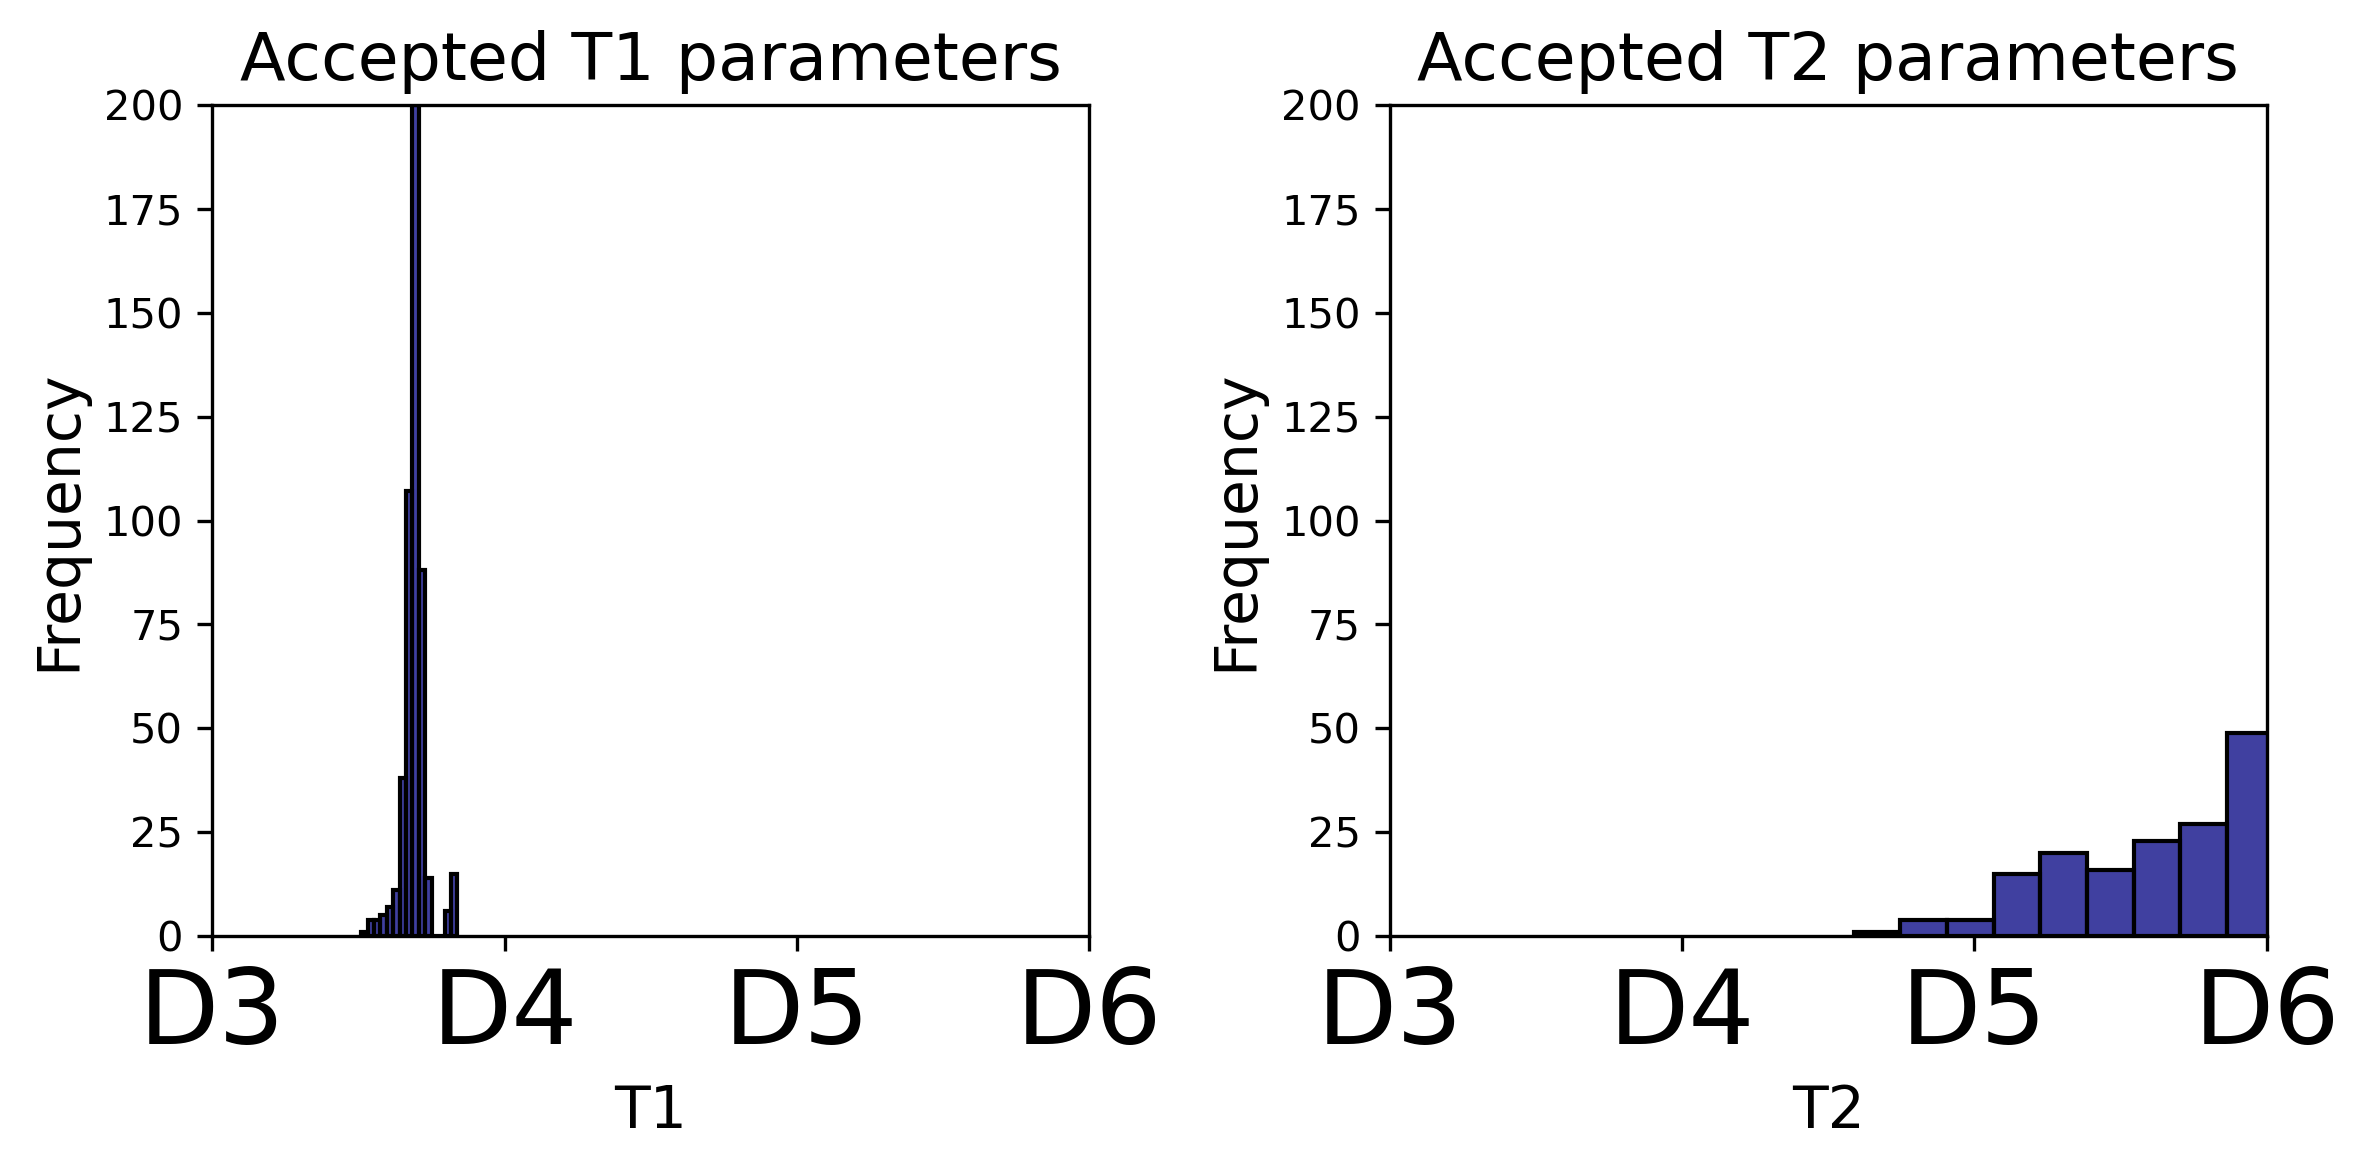

In [23]:
def plot_hist(ax, col, title,time):
    sns.histplot(df[col], color='navy', bins=15, ax=ax)
    ax.set_xlim(0, 300)
    ax.set_ylim(0, 200)
    ax.set_xlabel(time, fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xticks([0, 100, 200, 300])  
    ax.set_xticklabels(['D3','D4', 'D5', 'D6'], fontsize=25) 
    x_values = np.linspace(0, 300, 400) 
    y_values = 350 * 0.5 * (np.tanh(10 * (x_values - np.mean(df[col]))) + 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300)
plot_hist(axes[0], 'T1', 'Accepted T1 parameters','T1')
plot_hist(axes[1], 'T2', 'Accepted T2 parameters','T2')

plt.tight_layout()
plt.show()

#### **4.2** Compare simulated and experimental proportions

In [26]:
adata

,PreNeural,p0/p1,p2,pMN,MNDiff,DP,EarlyVentral,Early p3,p3,FP
D3.5,25.704320,22.189428,0.000000,0.000000,0.000000,0.000000,0.000000,0.134156,0.000000,0.000000
D4,4.163192,18.955674,24.562191,2.713452,0.006415,1.250882,1.635769,1.821797,0.070563,0.365642
D5,4.337276,3.867152,5.656658,20.723385,0.485290,11.336063,4.458599,8.113436,3.397028,2.259630
D6,0.556586,1.437848,0.123686,13.218924,33.750773,22.309833,2.118120,4.607297,5.720470,7.884972


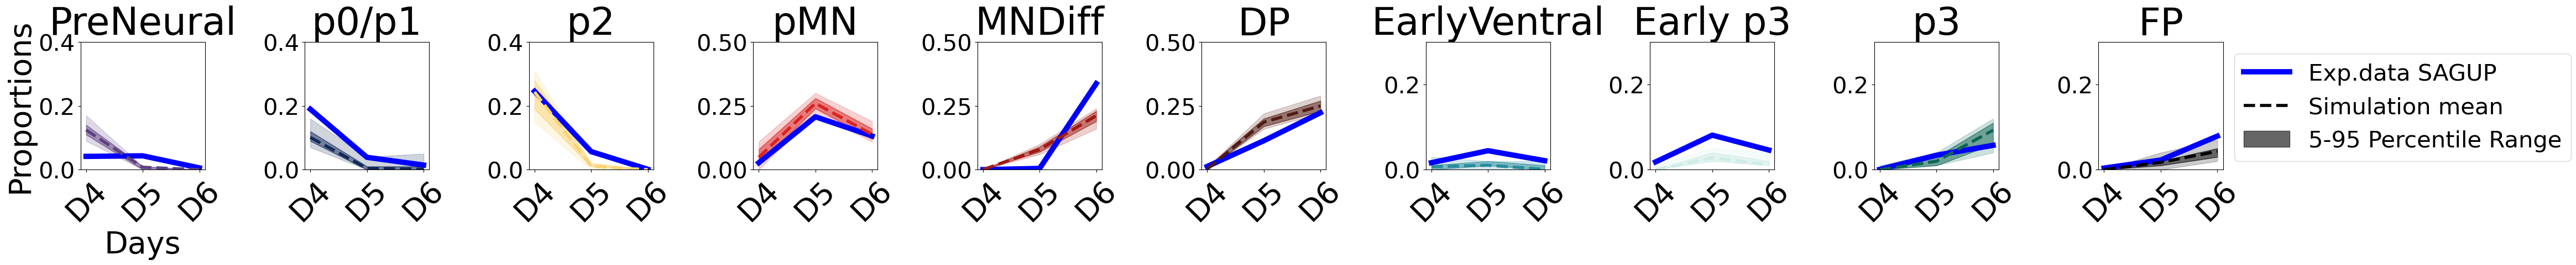

In [28]:
# Import the function to plot the distributions of simulated data
from prediction_global_earlypulse import process_simulations

# Process simulations
simulation_accepted, dist, simulation_mean = process_simulations(500, h, data)
timepoints=['D3','D3.5','D4','D5','D6','D7']

states=['PreNeural','p0/p1','p2','pMN','MNDiff','DP','EarlyVentral','Early p3','p3','FP']
states_byDay = [f"{state}-{day}" for day in timepoints for state in states]
simulation=pd.DataFrame(np.array(simulation_accepted),columns=states_byDay)

# plot simulated proportions
plot_tendencies(states, plotdays, simulation[cols], adata, colorpalette)

#### **4.3** Bump functions modelling the morphogen response

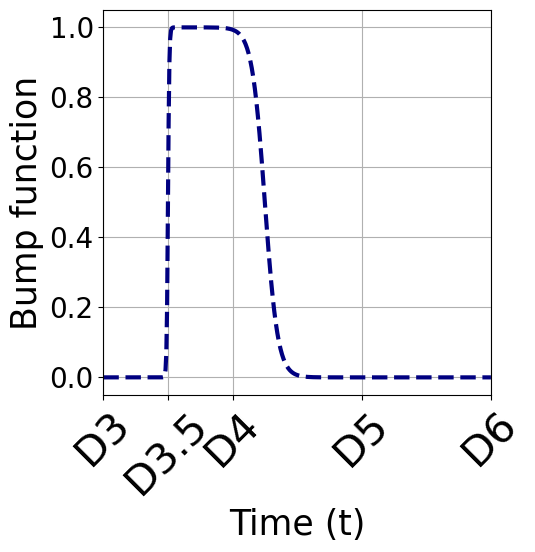

In [31]:
# Define the functions
def memory1(ts,t1):
    return 0.5 * (np.tanh(1 * (ts - t1)) + 1)
def memory2(ts,t2):
    return 0.5 * (np.tanh(0.1 * (ts - t2)) + 1)
def composite_function(ts,t1,t2):
    return memory1(ts,t1) * (1 - memory2(ts,t2))

# Time range for the plot
ts = np.linspace(0, 300, 500)
# Compute the values
composite_values = composite_function(ts,50,125)

# Plot the functions for first simulation
plt.figure(figsize=(5, 5),dpi=100)
plt.plot(ts, composite_values, color='navy', linestyle="--", linewidth=3)
plt.xlabel("Time (t)", fontsize=25)
plt.ylabel("Bump function", fontsize=25)
plt.grid(True)
plt.xticks(ticks=np.arange(0, 301, 50),fontsize=20)  # Define ticks explicitly
plt.yticks(fontsize=20) 
plt.xticks(ticks=[0,50, 100, 200, 300], labels=["D3","D3.5", "D4", "D5", "D6"], fontsize=30,rotation=45)
plt.xlim(0, 300)
plt.show()

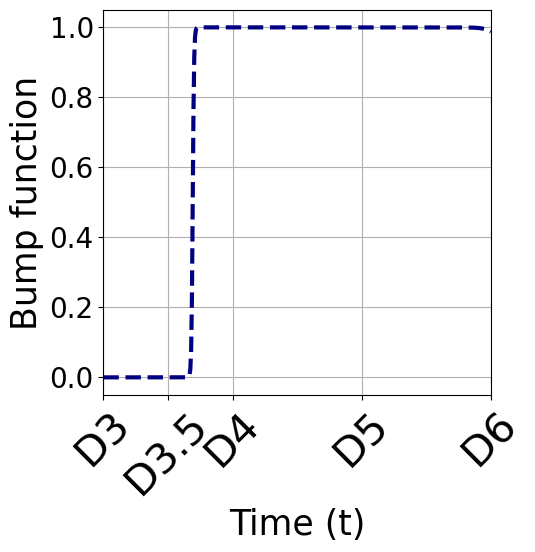

In [33]:
# Compute the values
composite_values2 = composite_function(ts,df['T1'].mean(),df['T2'].mean())

# Plot the functions using the mean of T1,T2 fitted parameters. Shows no response to signal change
plt.figure(figsize=(5, 5),dpi=100)
plt.plot(ts, composite_values2, color="navy", linestyle="--", linewidth=3)
plt.xlabel("Time (t)", fontsize=25)
plt.ylabel("Bump function", fontsize=25)
plt.grid(True)
plt.xticks(ticks=np.arange(0, 301, 50))  # Define ticks explicitly
plt.xticks(ticks=[0,50, 100, 200, 300], labels=["D3","D3.5", "D4", "D5", "D6"], fontsize=30,rotation=45)
plt.yticks(fontsize=20) 
plt.xlim(0, 300)
plt.show()